In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [7]:
interactions = pd.read_csv("../data/interactions.csv")
products = pd.read_csv("../data/products.csv")
users = pd.read_csv("../data/users.csv")


In [9]:
interactions.head()


,user_id,product_id,event_type,timestamp
0,349,73,add_to_cart,2025-09-08 17:25:19.936687
1,320,10,add_to_cart,2025-07-13 17:25:19.936687
2,421,61,click,2025-07-21 17:25:19.936687
3,468,50,add_to_cart,2025-06-30 17:25:19.936687
4,49,122,click,2025-12-12 17:25:19.936687


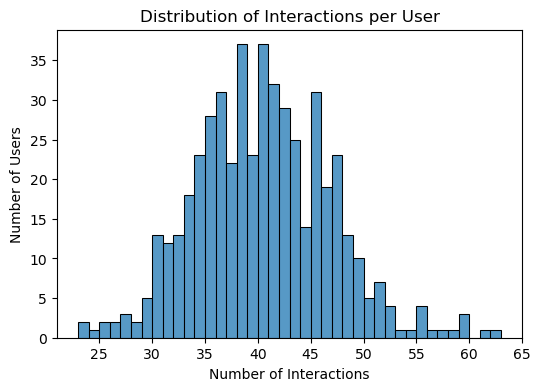

In [11]:
user_counts = interactions.groupby("user_id").size()

plt.figure(figsize=(6,4))
sns.histplot(user_counts, bins=40)
plt.title("Distribution of Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.show()


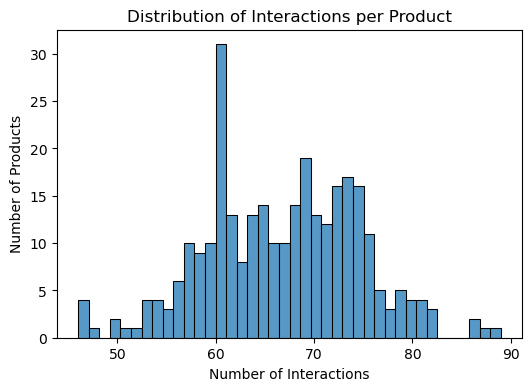

In [13]:
product_counts = interactions.groupby("product_id").size()

plt.figure(figsize=(6,4))
sns.histplot(product_counts, bins=40)
plt.title("Distribution of Interactions per Product")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Products")
plt.show()


In [15]:
purchases = interactions[interactions["event_type"] == "purchase"]


In [17]:
user_product = pd.crosstab(
    purchases["user_id"],
    purchases["product_id"]
)


In [19]:
co_occurrence = user_product.T.dot(user_product)


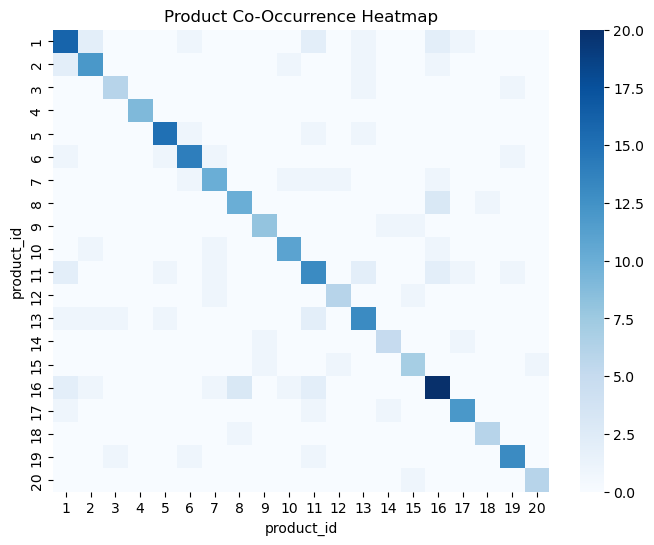

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence.iloc[:20, :20], cmap="Blues")
plt.title("Product Co-Occurrence Heatmap")
plt.show()


In [23]:
user_activity = interactions.groupby("user_id").size().reset_index(name="interaction_count")


In [25]:
def classify_user(x):
    if x < 5:
        return "New User"
    elif x < 20:
        return "Active User"
    else:
        return "Power User"

user_activity["segment"] = user_activity["interaction_count"].apply(classify_user)


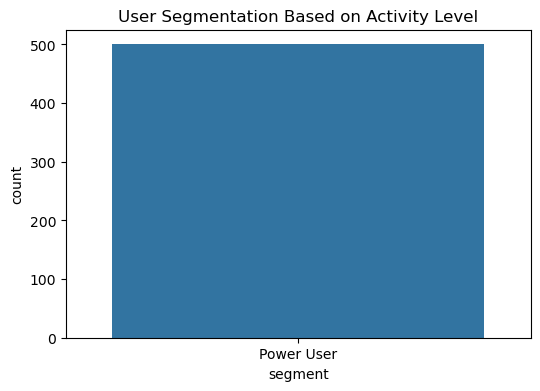

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="segment", data=user_activity)
plt.title("User Segmentation Based on Activity Level")
plt.show()
